<a href="https://colab.research.google.com/github/Gafinhords/Restaurant-visitors-forecast/blob/main/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
air_reserve = pd.read_csv('/content/air_reserve.csv')

air_store_info = pd.read_csv('/content/air_store_info.csv')

air_visit_data = pd.read_csv('/content/air_visit_data.csv')

date_info = pd.read_csv('/content/date_info.csv')

hpg_reserve = pd.read_csv('/content/hpg_reserve.csv')

hpg_store_info = pd.read_csv('/content/hpg_store_info.csv')

store_id_relation = pd.read_csv('/content/store_id_relation.csv')

In [ ]:
air_visit_data.head()

,air_store_id,visit_date,visitors
0,air_ba937bf13d40fb24,2016-01-13,25
1,air_ba937bf13d40fb24,2016-01-14,32
2,air_ba937bf13d40fb24,2016-01-15,29
3,air_ba937bf13d40fb24,2016-01-16,22
4,air_ba937bf13d40fb24,2016-01-18,6


In [ ]:
date_info.head()

,calendar_date,day_of_week,holiday_flg
0,2016-01-01,Friday,1
1,2016-01-02,Saturday,1
2,2016-01-03,Sunday,1
3,2016-01-04,Monday,0
4,2016-01-05,Tuesday,0


<Axes: xlabel='visit_date'>

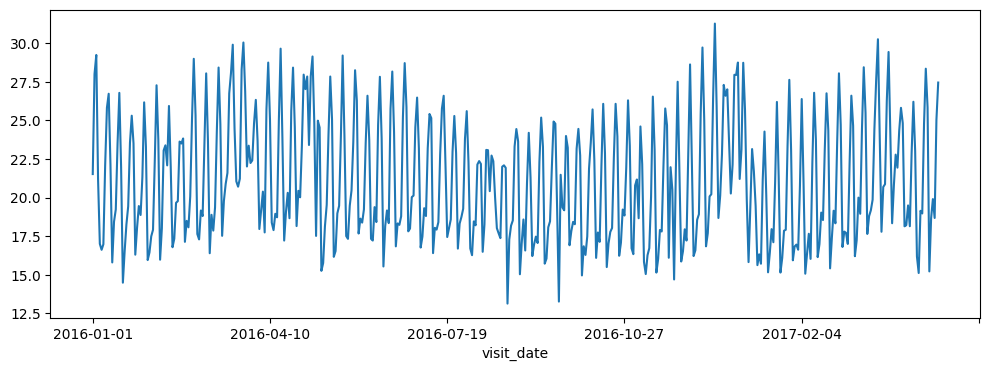

In [ ]:
air_visit_data.groupby('visit_date')['visitors'].mean().plot(figsize=(12,4))

<Axes: xlabel='month'>

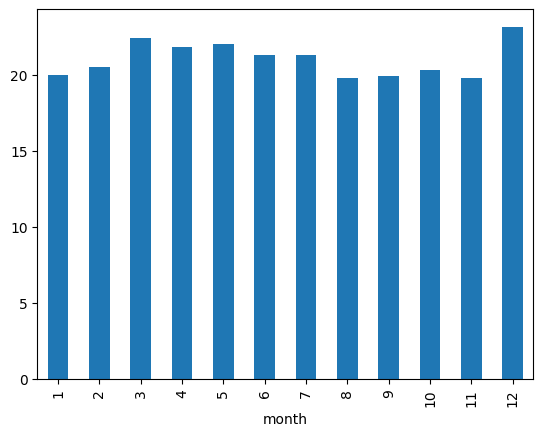

In [ ]:
air_visit_data.groupby('month')['visitors'].mean().plot(kind = 'bar')

Заметим что самое большое кол-во посетитетелей 12 месяца, то есть в декабре, а также наибольший приток с марта по июнь. Я бы связал это с праздниками

<Axes: xlabel='dow'>

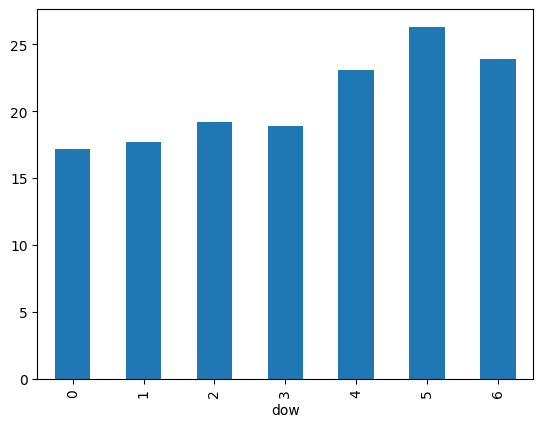

In [ ]:
air_visit_data.groupby('dow')['visitors'].mean().plot(kind = 'bar')

Также если смотреть по дням недели, то очевидно, что наибольшее кол-во посейтителей будет в выходные, включая пятницу, что подтверждается цифрами

<Axes: xlabel='month', ylabel='dow'>

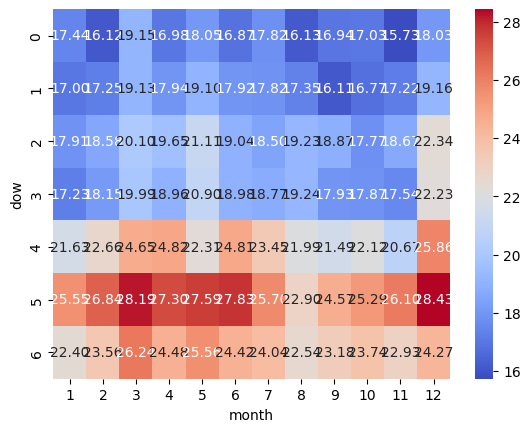

In [ ]:
pivot = air_visit_data.pivot_table(index='dow', columns='month', values='visitors', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='coolwarm')

По этой тепловой карте можем отследить, что менее охотно люди идут с понедельника по четверг почти весь год. Лишь только в декабре, среднее кол-во посейтителей в среду и четверг увеличивается до среднестатистического.
Активнее всего же люди идут в субботу марта и субботу декабря, что также связано с праздниками, например международным женским днем, днями рождения, а также новым годом. Единственный месяц, когда даже в выходные идет просадка по посейтителям - август.  

In [ ]:
import numpy as np

In [ ]:
def to_raw_schema(visits: pd.DataFrame) -> pd.DataFrame:
    df = visits.rename(columns={
        'air_store_id': 'restaurant_id',
        'visit_date': 'date',
        'visitors': 'guests',
    }).copy()

    df['date'] = pd.to_datetime(df['date'])
    df['restaurant_id'] = df['restaurant_id'].astype('category').cat.codes.astype('int64')

    rng = np.random.default_rng(42)
    avg_check = 2500.0
    noise = rng.normal(1.0, 0.05, len(df))
    df['revenue'] = (df['guests'] * avg_check * noise).astype('float64')

    return (
        df[['date', 'restaurant_id', 'guests', 'revenue']]
        .sort_values(['restaurant_id', 'date'])
        .reset_index(drop=True)
    )

In [ ]:
df = to_raw_schema(air_visit_data)
print(df.columns.tolist())
print(df.head())

['date', 'restaurant_id', 'guests', 'revenue']
        date  restaurant_id  guests       revenue
0 2016-07-01              0      35  84163.265229
1 2016-07-02              0       9  21829.692759
2 2016-07-04              0      20  52201.928778
3 2016-07-05              0      25  64550.348659
4 2016-07-06              0      29  71175.363221


In [ ]:
date_info['calendar_date'] = pd.to_datetime(date_info['calendar_date'])

df = df.merge(
    date_info[['calendar_date', 'holiday_flg']].rename(columns={'calendar_date': 'date'}),
    on='date', how='left'
)

df['dow'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['is_weekend'] = df['dow'].isin([4, 5, 6]).astype(int)   # пт, сб, вс — как у тебя было
df['year_month'] = df['date'].dt.to_period('M').astype(str)

print(df.columns.tolist())
print(df.head())

['date', 'restaurant_id', 'guests', 'revenue', 'holiday_flg', 'dow', 'month', 'year', 'is_weekend', 'year_month']
        date  restaurant_id  guests       revenue  holiday_flg  dow  month  \
0 2016-07-01              0      35  84163.265229            0    4      7   
1 2016-07-02              0       9  21829.692759            0    5      7   
2 2016-07-04              0      20  52201.928778            0    0      7   
3 2016-07-05              0      25  64550.348659            0    1      7   
4 2016-07-06              0      29  71175.363221            0    2      7   

   year  is_weekend year_month  
0  2016           1    2016-07  
1  2016           1    2016-07  
2  2016           0    2016-07  
3  2016           0    2016-07  
4  2016           0    2016-07  


In [ ]:
top_ids = (
    air_visit_data.groupby('air_store_id')['visitors']
    .agg(['count', 'mean'])
    .query('count > 300')
    .sort_values('mean', ascending = False)
    .head(5)
    .index
)


In [ ]:
date_info['calendar_date'] = pd.to_datetime(date_info['calendar_date'])
df = air_visit_data.merge(
    date_info[['calendar_date', 'holiday_flg']],
    left_on = 'date',
    right_on = 'calendar_date',
    how = 'left'
).drop(columns = 'calendar_date')

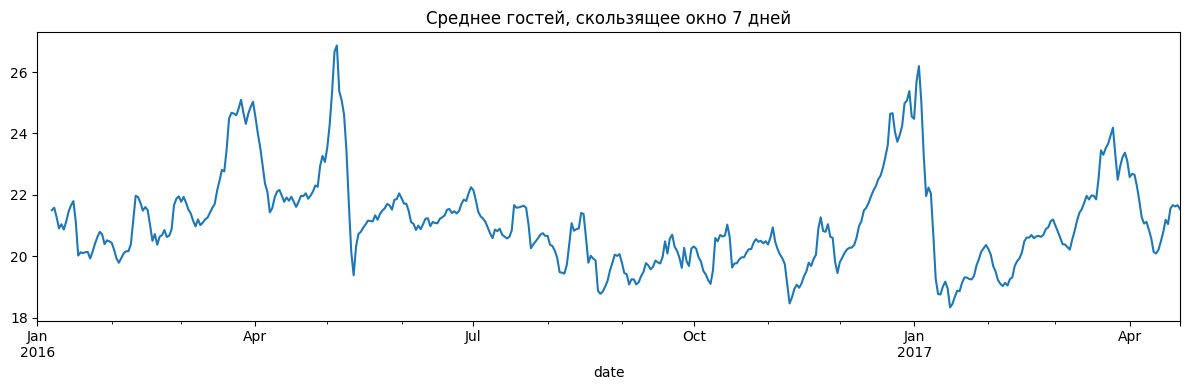

In [ ]:
daily = df.groupby('date')['visitors'].mean()
daily.rolling(7).mean().plot(figsize=(12, 4), title='Среднее гостей, скользящее окно 7 дней')

plt.tight_layout()
plt.show()

Пиковые значние по среднему кол-ву посейтителей достигает в конце марта - начале апреля. Так как датасет составлен на японских ресторанах, предположу, что это связано с праздником цветения сакуры. Также самое большое среднее кол-во посейтителей приходится на конец года - новый год

AttributeError: Rectangle.set() got an unexpected keyword argument 'title'

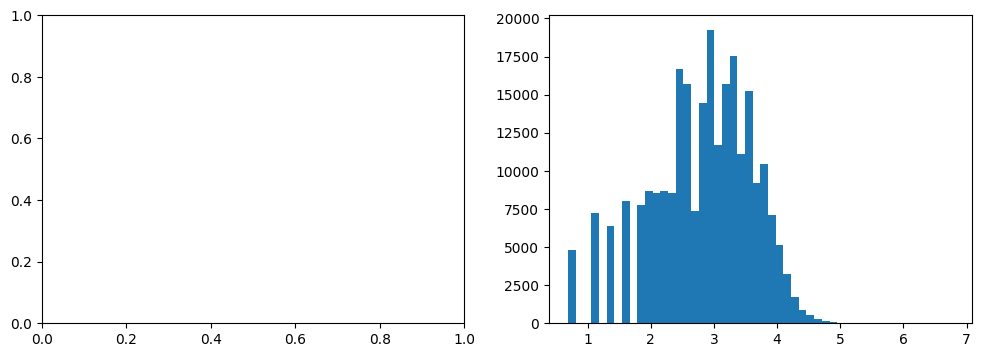

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

np.log1p(df['guests']).hist(bins=50, title='log1p(guests)')

axes[0].hist(df['guests'], bins=50)
axes[0].set_title('Распределение guests')
axes[0].set_xlabel('Гости за день, чел.')
axes[0].set_ylabel('Число наблюдений')

axes[1].boxplot(df['visitors'], vert=False)
axes[1].set_title('Boxplot guests')
axes[1].set_xlabel('Гости за день, чел.')

plt.tight_layout()
plt.show()

df['guests'].describe()

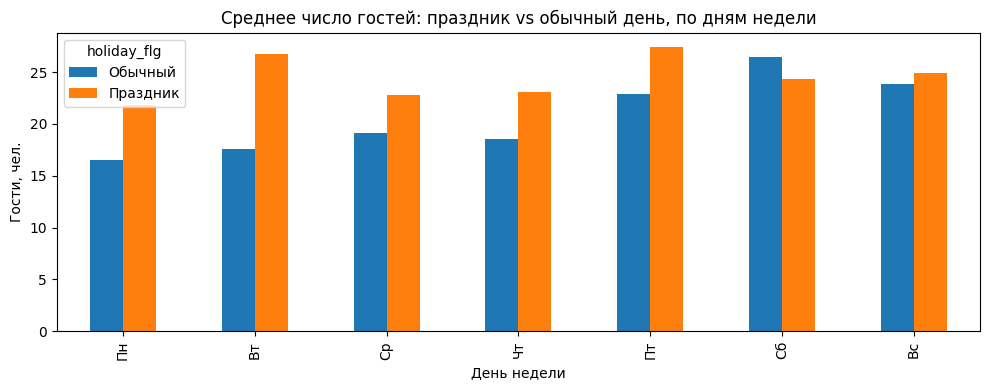

Пн    5.33
Вт    9.22
Ср    3.60
Чт    4.51
Пт    4.55
Сб   -2.07
Вс    1.04
dtype: float64
Средняя разница: 3.74


In [ ]:
dow_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

pivot = df.pivot_table(
    index='dow', columns='holiday_flg', values='guests', aggfunc='mean'
)
pivot.index = dow_names

fig, ax = plt.subplots(figsize=(10, 4))
pivot.plot(kind='bar', ax=ax)
ax.set_title('Среднее число гостей: праздник vs обычный день, по дням недели')
ax.set_xlabel('День недели')
ax.set_ylabel('Гости, чел.')
ax.legend(title='holiday_flg', labels=['Обычный', 'Праздник'])
plt.tight_layout()
plt.show()

# Насколько праздник добавляет сверх дня недели
print((pivot[1] - pivot[0]).round(2))
print('Средняя разница:', round((pivot[1] - pivot[0]).mean(), 2))

holiday_flg даёт независимый от дня недели прирост, в среднем +3,7 гостя. Эффект максимален в будни вт, пн, чт. Это значит, что праздничные дни поднимают слабые почти до уровня выходного. В субботу эффект отрицательный. Вероятно часть гостей перераспределяется на другие праздничные дни. Признак holiday_flg стоит включать в модель, но одного его мало, нужен ещё признак день после праздника для мониторинга постпраздничного спада

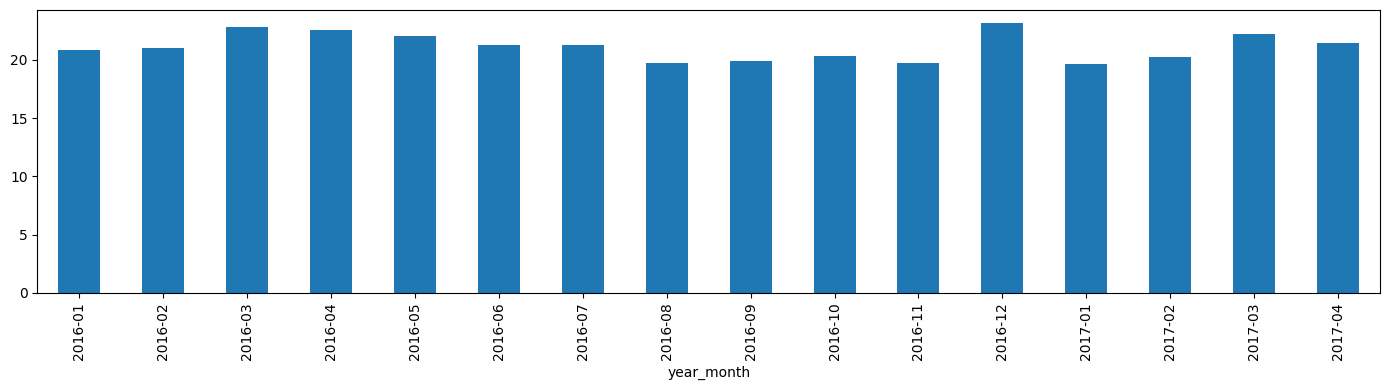

In [ ]:
by_month = df.groupby('month')['guests'].mean()

df['year_month'] = df['date'].dt.to_period('M').astype(str)
df.groupby('year_month')['guests'].mean().plot(kind='bar', figsize=(14, 4))


plt.tight_layout()
plt.show()

In [ ]:
full_range = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
full_idx = pd.MultiIndex.from_product(
    [df['restaurant_id'].unique(), full_range],
    names=['restaurant_id', 'date']
)
full = pd.DataFrame(index=full_idx).reset_index()

merged = full.merge(
    df[['restaurant_id', 'date', 'guests']],
    on=['restaurant_id', 'date'], how='left'
)

merged['is_missing'] = merged['guests'].isna()
print('Доля пропусков:', round(merged['is_missing'].mean() * 100, 2), '%')
print('Пропусков всего:', merged['is_missing'].sum())

Доля пропусков: 36.38 %
Пропусков всего: 144154


Ресторанов с 0% пропусков: 0
Ресторанов с <10% пропусков: 106
Ресторанов с 10–50% пропусков: 544
Ресторанов с >50% пропусков: 171


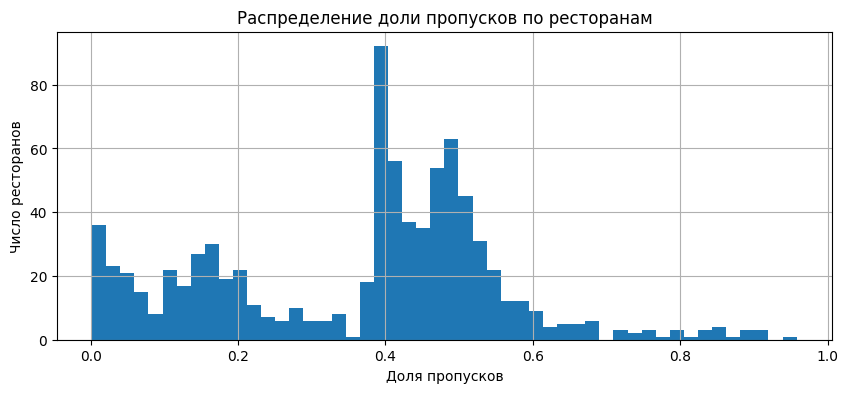

In [ ]:
by_store = merged.groupby('restaurant_id')['is_missing'].agg(['mean', 'sum'])
print('Ресторанов с 0% пропусков:', (by_store['mean'] == 0).sum())
print('Ресторанов с <10% пропусков:', (by_store['mean'] < 0.1).sum())
print('Ресторанов с 10–50% пропусков:', ((by_store['mean'] >= 0.1) & (by_store['mean'] < 0.5)).sum())
print('Ресторанов с >50% пропусков:', (by_store['mean'] > 0.5).sum())

by_store['mean'].hist(bins=50, figsize=(10, 4))
plt.title('Распределение доли пропусков по ресторанам')
plt.xlabel('Доля пропусков')
plt.ylabel('Число ресторанов')
plt.show()

На графике выше мы видим бимодальное распределение, то есть 2 горба. Такое распределение означает, что часть ресторанов отчитывалась не каждый день (работали, но не подавали данные в систему), а часть действительно открывалась или закрывалась в середине периода

Будем фильтровать до ресторанов с долей пропусков <10%. Их 186 (0% + <10%) То есть мы оставили рестораны с наиболее полной историей, чтобы не путать закрытые дни со сбоями выгрузки

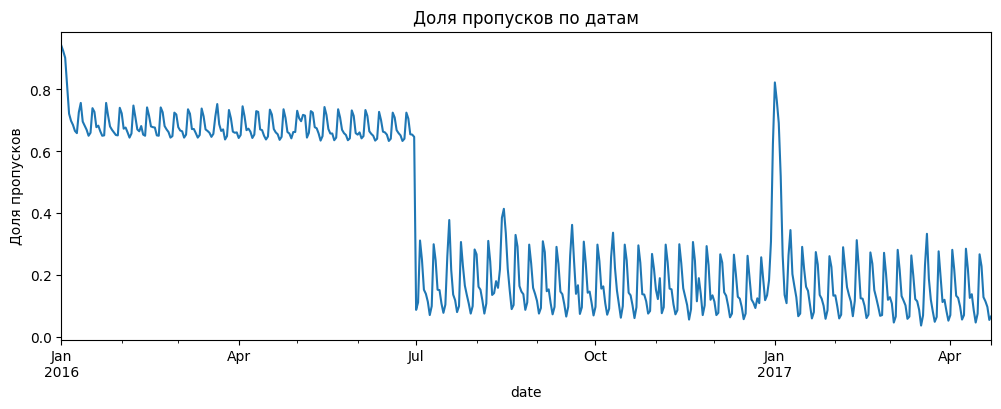

date
2016-01-01    0.942099
2016-01-02    0.924005
2016-01-03    0.902292
2017-01-01    0.822678
2016-01-04    0.810615
2017-01-02    0.763571
2016-01-24    0.756333
2016-01-11    0.756333
2016-03-21    0.752714
2016-02-07    0.747889
Name: is_missing, dtype: float64


In [ ]:
by_date = merged.groupby('date')['is_missing'].mean()
by_date.plot(figsize=(12, 4), title='Доля пропусков по датам')
plt.ylabel('Доля пропусков')
plt.show()

print(by_date.sort_values(ascending=False).head(10))

Что это значит. До июля 2016 в датасете было мало ресторанов, а с июля подключилась большая часть. То есть 70% пропусков в первой половине 2016 это не закрытые дни, а рестораны, которых тогда ещё не было в системе

Это критично для модели. Так как если мы обучим модель на периоде, где половина ресторанов отсутствует, а валидироваться будем на периоде где они есть, то метрики будут нечестными. Тогда нам нужно либо:

1)Обрезать данные до июля 2016 (тогда 10 месяцев истории маловато для годовой сезонности, но честно)

2)Взять только рестораны с полной историей (те у кого first_seen = январь 2016 и last_seen = апрель 2017)

3)И то и другое. Рестораны с полной историей, период - весь доступный

In [ ]:
tmp = merged.merge(
    df[['date']].drop_duplicates().assign(dow=lambda d: d['date'].dt.dayofweek),
    on='date', how='left'
)
print(tmp.groupby('dow')['is_missing'].mean().round(3))

dow
0    0.438
1    0.361
2    0.347
3    0.326
4    0.295
5    0.314
6    0.468
Name: is_missing, dtype: float64


Понедельник и воскресенье это пик пропусков. Я предположу, что многие заведения закрыты в понедельник и частично в воскресенье вечером. Пятница — минимум пропусков, все работают

Это важный сигнал. Пропуски не случайны, они связаны с бизнес логикой. Значит заполнять их нулями правильно (ресторан был закрыт, гостей 0), но только для тех ресторанов, у которых такая структура стабильна.

Но нужно быть осторожным, если у ресторана пропуск в пятницу это скорее сбой выгрузки, а не закрытие

In [ ]:
first_last = merged.groupby('restaurant_id').agg(
    first_seen=('date', lambda s: s[merged.loc[s.index, 'is_missing'] == False].min() if (merged.loc[s.index, 'is_missing'] == False).any() else pd.NaT),
    last_seen=('date', lambda s: s[merged.loc[s.index, 'is_missing'] == False].max() if (merged.loc[s.index, 'is_missing'] == False).any() else pd.NaT),
)
real = merged[~merged['is_missing']]
span = real.groupby('restaurant_id')['date'].agg(['min', 'max', 'count'])
span.head()

,min,max,count
restaurant_id,,,
0,2016-07-01,2017-04-22,232
1,2016-10-03,2017-04-22,149
2,2016-01-03,2017-04-22,396
3,2016-07-03,2017-04-22,116
4,2016-07-01,2017-04-22,251


Ресторан 2 живёт с января 2016, остальные с июля. Если мы возьмем все 800, у нас будет датасет зомби, где половина ресторанов имеет историю в два раза длиннее других

In [ ]:
by_store = merged.groupby('restaurant_id')['is_missing'].mean()

good_stores = by_store[by_store < 0.1].index

real = merged[~merged['is_missing'] & merged['restaurant_id'].isin(good_stores)]
span = real.groupby('restaurant_id')['date'].agg(['min', 'max'])
span['days'] = (span['max'] - span['min']).dt.days
full_stores = span[span['days'] > 400].index

df_clean = df[df['restaurant_id'].isin(full_stores)].copy()
print('Ресторанов осталось:', df_clean['restaurant_id'].nunique())
print('Строк:', len(df_clean))

Ресторанов осталось: 106
Строк: 48591


Доля пропусков: 4.1 %


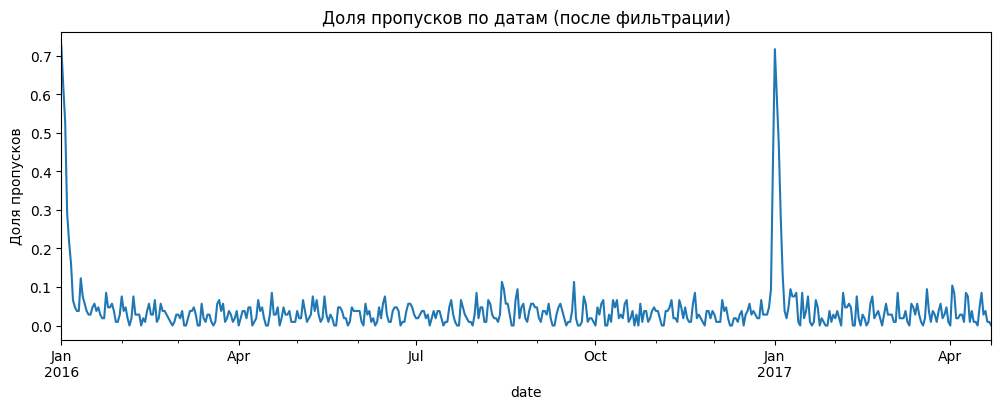

In [ ]:
full_range = pd.date_range(df_clean['date'].min(), df_clean['date'].max(), freq='D')
full_idx = pd.MultiIndex.from_product(
    [df_clean['restaurant_id'].unique(), full_range],
    names=['restaurant_id', 'date']
)
full2 = pd.DataFrame(index=full_idx).reset_index()

merged2 = full2.merge(
    df_clean[['restaurant_id', 'date', 'guests']],
    on=['restaurant_id', 'date'], how='left'
)
merged2['is_missing'] = merged2['guests'].isna()

print('Доля пропусков:', round(merged2['is_missing'].mean() * 100, 2), '%')

by_date2 = merged2.groupby('date')['is_missing'].mean()
by_date2.plot(figsize=(12, 4), title='Доля пропусков по датам (после фильтрации)')
plt.ylabel('Доля пропусков')
plt.show()

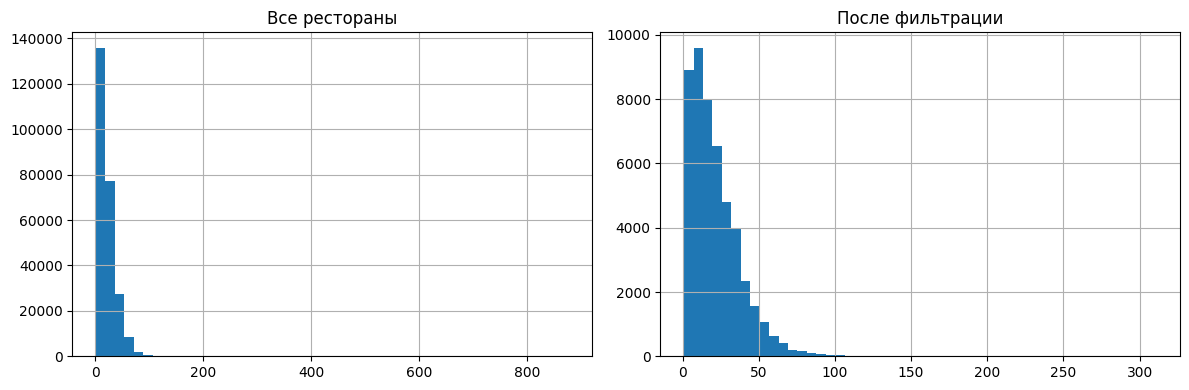

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['guests'].hist(bins=50, ax=axes[0])
axes[0].set_title('Все рестораны')
df_clean['guests'].hist(bins=50, ax=axes[1])
axes[1].set_title('После фильтрации')
plt.tight_layout()
plt.show()

In [ ]:
df_clean.to_csv('/content/df_clean.csv', index=False)

После фильтрации доля пропусков упала с 36% до 4.1%. Остались два кластера: край истории (январь 2016) и 1 января 2017. Это реальное закрытие ресторанов на Новый год. Остальные пропуски распределены равномерно и совпадают с выходными днями, что подтверждает гипотезу пропуск = закрытый день для этой части данных. Заполнять нулями такие пропуски корректно

In [ ]:
stats = df_clean.groupby('restaurant_id')['guests'].agg(
    median='median',
    q1=lambda s: s.quantile(0.25),
    q3=lambda s: s.quantile(0.75),
)
stats['iqr'] = stats['q3'] - stats['q1']
stats['upper'] = stats['q3'] + 3 * stats['iqr']

df_clean = df_clean.merge(stats[['upper']], left_on='restaurant_id', right_index=True)
df_clean['is_outlier'] = df_clean['guests'] > df_clean['upper']

print('Выбросов:', df_clean['is_outlier'].sum(), f"({df_clean['is_outlier'].mean()*100:.2f}%)")

Выбросов: 102 (0.21%)


In [ ]:
out_hol = df_clean[df_clean['is_outlier']]
print('Из', len(out_hol), 'выбросов в праздники:', out_hol['holiday_flg'].sum())
print('Доля праздничных среди выбросов:', round(out_hol['holiday_flg'].mean(), 3))
print('Доля праздничных во всём датасете:', round(df_clean['holiday_flg'].mean(), 3))

Из 102 выбросов в праздники: 11
Доля праздничных среди выбросов: 0.108
Доля праздничных во всём датасете: 0.056


Обнаружено 102 выброса (0.21%) по правилу 3×IQR внутри ресторана. Проверка показала что 10.8% из них приходятся на праздничные дни, вдвое выше базовой доли праздников в данных (5.6%). Это подтверждает что часть выбросов это реальные праздничные пики, а не ошибки. Оставшиеся 89% вероятно, локальные события ресторанов (корпоративы или банкеты) или крупные заведения с низким порогом IQR. Решение: выбросы не удалять. Модель на градиентном бустинге устойчива к редким пикам, а сами пики это часть бизнеса, которую модель должна знать